# Stitching function 

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import correlate, correlation_lags
from pathlib import Path
import napari

# ==========================================
# 0. PRE-PROCESSING UTILITIES
# ==========================================
def apply_db_cutoff(vol, cutoff_db=-5):
    """
    Zeros out voxels more than 'cutoff_db' below the peak.
    Returns the thresholded volume and the sparsity percentage.
    """
    v_abs = np.abs(vol)
    v_max = np.max(v_abs)
    if v_max == 0:
        return vol, 0.0
    
    # Linear threshold = Vmax * 10^(dB / 20)
    thresh = v_max * (10**(cutoff_db / 20))
    
    # Create mask and apply
    v_thresh = np.where(v_abs >= thresh, vol, 0)
    
    # Calculate how much of the volume is now zeros
    sparsity = (np.count_nonzero(v_thresh == 0) / v_thresh.size) * 100
    return v_thresh.astype(np.float32), sparsity

# ==========================================
# 1. THE STITCHER ENGINE (Profile-Based Consensus)
# ==========================================
def run_stitcher_test(vol1, vol2, axis=2, grid=(60, 20), expected=0, tolerance=200, cutoff_db=-5):
    v1, s1 = apply_db_cutoff(vol1, cutoff_db)
    v2, s2 = apply_db_cutoff(vol2, cutoff_db)
    
    print(f"[Pre-Process] Applied {cutoff_db}dB Cutoff.")
    print(f" -> Vol1 Sparsity: {s1:.1f}% | Vol2 Sparsity: {s2:.1f}%")

    ignore_top = 30
    z_dim, y_dim, x_dim = v1.shape
    z_start, z_end = ignore_top, z_dim
    
    tile_z = (z_end - z_start) // grid[0]
    tile_y = y_dim // grid[1]
    
    all_shifts = []
    all_weights = []
    
    for r in range(grid[0]):
        for c in range(grid[1]):
            zs, ze = z_start + (r * tile_z), z_start + ((r + 1) * tile_z)
            ys, ye = c * tile_y, (c + 1) * tile_y
            
            prof1 = np.max(np.abs(v1[zs:ze, ys:ye, :]), axis=(0, 1))
            prof2 = np.max(np.abs(v2[zs:ze, ys:ye, :]), axis=(0, 1))

            if np.std(prof1) < 1e-6 or np.max(prof1) == 0:
                continue

            p1_n = (prof1 - np.mean(prof1)) / (np.std(prof1) + 1e-10)
            p2_n = (prof2 - np.mean(prof2)) / (np.std(prof2) + 1e-10)
            
            corr = correlate(p1_n, p2_n, mode='full')
            lags = correlation_lags(len(p1_n), len(p2_n), mode='full')
            
            mask = (lags >= expected - tolerance) & (lags <= expected + tolerance)
            if not np.any(mask): continue
            corr[~mask] = -np.inf 

            peak_idx = np.argmax(corr)
            all_shifts.append(lags[peak_idx])
            all_weights.append(corr[peak_idx])

    if not all_shifts:
        raise ValueError(f"No features survived the {cutoff_db}dB cutoff.")

    lag_min, lag_max = np.min(all_shifts), np.max(all_shifts)
    bins = np.arange(lag_min, lag_max + 2) - 0.5
    counts, bin_edges = np.histogram(all_shifts, bins=bins, weights=all_weights)
    final_shift = int(bin_edges[np.argmax(counts)] + 0.5)
    
    print(f"[Consensus Stitcher] Calculated Shift: {final_shift} pixels")
    
    return final_shift, v1

# ==========================================
# 2. STANDALONE STITCHER EXECUTION
# ==========================================
if __name__ == "__main__":
    IN_DIR = Path.cwd().parent / 'DATA' / '2D TFM Data' / 'FeC Smile 3MHz 04022026 Filtered'
    
    try:
        vol1_raw = np.load(IN_DIR / "FeC_40_4_filtered_3D_TFM.npy")
        vol2_raw = np.load(IN_DIR / "FeC_40_3_filtered_3D_TFM.npy")
    except FileNotFoundError:
        print("Data not found.")
        exit()

    stitch_shift, v1_thresholded = run_stitcher_test(vol1_raw, vol2_raw, grid=(120, 40), cutoff_db=-10)

    # --- THE FIX: ROBUST CONTRAST LIMITS ---
    # Raw Data Limits
    clim_raw = sorted([float(np.percentile(vol1_raw, 0.1)), float(np.percentile(vol1_raw, 99.9))])
    if clim_raw[0] == clim_raw[1]: clim_raw = [clim_raw[0], clim_raw[0] + 1]

    # Thresholded Data Limits
    clim_thresh = sorted([float(np.min(v1_thresholded)), float(np.max(v1_thresholded))])
    if clim_thresh[0] == clim_thresh[1]: clim_thresh = [0, 1]

    viewer = napari.Viewer(title="Stitcher Result Testing (-5dB Cutoff)")

    # Layer 1: Raw Reference
    viewer.add_image(vol1_raw, name='Vol 1 (Raw)', colormap='cyan', contrast_limits=clim_raw, opacity=0.5)
    
    # Layer 2: The Hotspots (Sorted clim ensures no monotonically increasing error)
    viewer.add_image(v1_thresholded, name='Vol 1 (-5dB Hotspots)', colormap='yellow', contrast_limits=clim_thresh)

    # Layer 3: The shifted Volume 2
    trans = [0, 0, 0]; trans[2] = stitch_shift
    viewer.add_image(vol2_raw, name=f'Vol 2 (Shifted {stitch_shift}px)', 
                     colormap='magenta', blending='additive', translate=trans, contrast_limits=clim_raw)

    print(f"\nStitcher complete. Threshold limits used: {clim_thresh}")
    napari.run()

[Pre-Process] Applied -10dB Cutoff.
 -> Vol1 Sparsity: 0.1% | Vol2 Sparsity: 0.1%
[Consensus Stitcher] Calculated Shift: 121 pixels

Stitcher complete. Threshold limits used: [-10.0, 0.0]


# Validation function

[Validation] Best Shift: 199


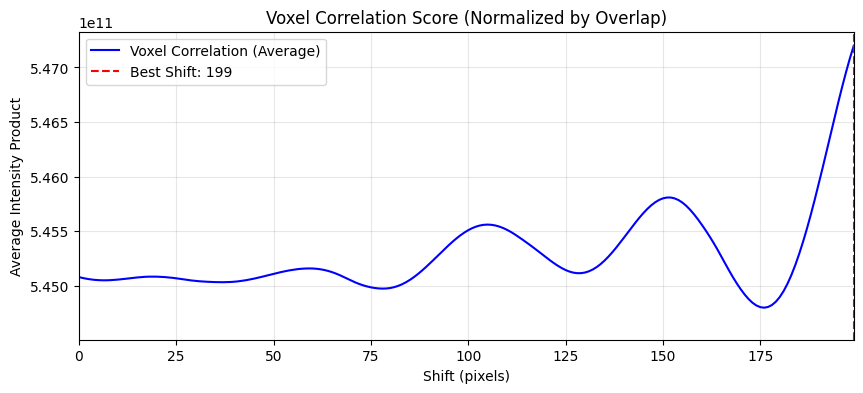

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import correlate, correlation_lags
from pathlib import Path
import napari

def run_voxel_validation_stitcher(vol1, vol2, ignore_z=30):
    """
    Compares every voxel by summing products along the x-axis.
    Divides by the overlap count to remove area bias.
    """
    # 1. Crop the Z-axis to reduce systematic correlation (e.g., surface reflections)
    v1 = vol1[ignore_z:, :, :]
    v2 = vol2[ignore_z:, :, :]

    # 2. Collapse Y and Z to get a 1D signal
    # Every point is the sum of all voxels in that X-slice
    sig1 = np.sum(v1, axis=(0, 1))
    sig2 = np.sum(v2, axis=(0, 1))

    # 3. Perform Raw Cross-Correlation (Sum of Products)
    raw_corr = correlate(sig1, sig2, mode='full')
    lags = correlation_lags(len(sig1), len(sig2), mode='full')

    # 4. DIVIDE BY OVERLAP
    # Calculate the number of overlapping slices at every lag
    # This creates a weight array: e.g., if 10 slices overlap, overlap_counts[lag] = 10
    overlap_counts = np.convolve(np.ones(len(sig1)), np.ones(len(sig2)), mode='full')
    
    # Divide raw sum by the number of overlapping elements to get the average
    # We add 1e-10 to prevent division by zero at the extreme edges
    normalized_corr = raw_corr / (overlap_counts + 1e-10)

    # 5. Find the best shift (restricting to positive shifts)
    mask = (lags >= 0)
    valid_lags = lags[mask]
    valid_corr = normalized_corr[mask]
    
    best_idx = np.argmax(valid_corr)
    best_shift = valid_lags[best_idx]
    
    print(f"[Validation] Best Shift: {best_shift}")
    return best_shift, lags, normalized_corr

if __name__ == "__main__":
    IN_DIR = Path.cwd().parent / 'DATA' / '2D TFM Data' / 'FeC Smile 3MHz 04022026 Filtered'
    
    try:
        v1 = np.load(IN_DIR / "FeC_40_4_filtered_3D_TFM.npy")
        v2 = np.load(IN_DIR / "FeC_40_3_filtered_3D_TFM.npy")
    except FileNotFoundError:
        print("Data files not found.")
        exit()

    # 1. Run Validation
    shift, all_lags, all_corr = run_voxel_validation_stitcher(v1, v2, ignore_z=30)

    # 2. Plot Overlap-Corrected Score vs Shift
    plt.figure(figsize=(10, 4))
    plt.plot(all_lags, all_corr, color='blue', label='Voxel Correlation (Average)')
    plt.axvline(x=shift, color='red', linestyle='--', label=f'Best Shift: {shift}')
    plt.title("Voxel Correlation Score (Normalized by Overlap)")
    plt.xlabel("Shift (pixels)")
    plt.ylabel("Average Intensity Product")
    plt.xlim(0, max(all_lags))
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    # 3. Linear Blend Stitching
    L1, L2 = v1.shape[2], v2.shape[2]
    total_len = max(L1, shift + L2)
    stitched = np.zeros((v1.shape[0], v1.shape[1], total_len), dtype=np.float32)
    
    stitched[:, :, :L1] = v1
    overlap = L1 - shift
    if overlap > 0:
        ramp = np.linspace(0, 1, overlap).reshape(1, 1, overlap)
        v1_part = v1[:, :, shift:L1]
        v2_part = v2[:, :, :overlap]
        stitched[:, :, shift:L1] = (v1_part * (1-ramp)) + (v2_part * ramp)
        stitched[:, :, L1:] = v2[:, :, overlap:]
    else:
        stitched[:, :, shift:shift+L2] = v2

    # 4. View in Napari
    viewer = napari.Viewer(title=f"Voxel Validation (Shift: {shift})")
    viewer.add_image(stitched, colormap="viridis", name="Overlap-Corrected Assembly")
    napari.run()

# Search Engine

In [8]:
import numpy as np
from pathlib import Path

def validate_stitch_voxels(vol1, vol2, shift, ignore_top=30, axis=2):
    """
    GROUND TRUTH VALIDATION:
    Compares every individual voxel in the overlapping region.
    No grids, no profiles, no averaging. 
    """
    # 1. Slice off top Z-voxels to remove systematic surface reflections
    v1 = vol1[ignore_top:, :, :]
    v2 = vol2[ignore_top:, :, :]

    # 2. Extract overlapping regions based on the shift
    s1_len = v1.shape[axis]
    
    if shift >= 0:
        # Vol 1 overlap is at the end, Vol 2 overlap is at the start
        overlap_v1 = v1[:, :, shift:]
        overlap_v2 = v2[:, :, :overlap_v1.shape[axis]]
    else:
        abs_shift = abs(shift)
        overlap_v1 = v1[:, :, :s1_len-abs_shift]
        overlap_v2 = v2[:, :, abs_shift:]

    # 3. Handle potential size mismatches from rounding
    min_len = min(overlap_v1.shape[axis], overlap_v2.shape[axis])
    if min_len <= 0:
        return 0.0, 0
    
    # 4. Flatten the 3D "bricks" into 1D arrays
    # Every voxel now counts equally in the correlation
    flat1 = overlap_v1[:, :, :min_len].ravel()
    flat2 = overlap_v2[:, :, :min_len].ravel()

    # 5. Pearson Correlation Coefficient
    # Returns 1.0 for perfect alignment, ~0 for random noise
    correlation_matrix = np.corrcoef(flat1, flat2)
    score = correlation_matrix[0, 1]
    
    return score, flat1.size

# --- Simple Standalone Usage ---
if __name__ == "__main__":
    IN_DIR = Path.cwd().parent / 'DATA' / '2D TFM Data' / 'FeC Smile 3MHz 04022026 Filtered'
    
    # Load your volumes
    v1 = np.load(IN_DIR / "FeC_40_4_filtered_3D_TFM.npy")
    v2 = np.load(IN_DIR / "FeC_40_3_filtered_3D_TFM.npy")
    
    # INPUT THE SHIFT YOU WANT TO TEST
    test_shift = 31  # Change this to your calculated shift
    
    score, count = validate_stitch_voxels(v1, v2, test_shift)
    
    print(f"Validation for Shift {test_shift}:")
    print(f" -> Voxel Correlation: {score:.4f}")
    print(f" -> Based on {count:,} voxels")

Validation for Shift 31:
 -> Voxel Correlation: -0.0043
 -> Based on 12,506,000 voxels
